In [2]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use('science')
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

In [19]:
import math
import pickle
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import wandb


# NeurIPS-style, colorblind-safe method palette (consistent across all figures)
METHOD_PALETTE = {
    "full": "#4D4D4D",
    "random": "#1B9E77",
    "NMT": "#D95F02",
    "EVOS": "#7570B3",
    "adaptive_unbiased": "#D9A404",
    "adaptive_best": "#66A61E",
    "grid_linear": "#3A86C8",
    "adaptive_best_fast": "#E7298A",
    "adaptive_large_bias": "#A6761D",
    "adaptive_with_no_area": "#666666",
}

# Canonical display order also drives legend order.
DEFAULT_ORDER = [
    "full",
    "random",
    "NMT",
    "EVOS",
    "adaptive_unbiased",
    "adaptive_best",
    "grid_linear",
    "adaptive_best_fast",
    "adaptive_large_bias",
    "adaptive_with_no_area",
]

METHOD_COLORS = METHOD_PALETTE.copy()

METHOD_LABELS = {
    "adaptive_best_fast": "Adaptive (Best Fast)",
    "adaptive_best": "Adaptive (Best)",
    "adaptive_unbiased": "Adaptive (Unbiased)",
    "adaptive_large_bias": "Adaptive (Large Bias)",
    "adaptive_with_no_area": "Adaptive (No Area)",
    "grid_linear": "Grid Linear",
    "EVOS": "EVOS",
    "NMT": "NMT",
    "random": "Random",
    "full": "Full",
}

METHOD_LINESTYLES = {
    "full": "-",
    "random": "--",
    "NMT": "-",
    "EVOS": "-",
    "adaptive_unbiased": "--",
    "adaptive_best": "-",
    "grid_linear": "--",
    "adaptive_best_fast": "-",
    "adaptive_large_bias": ":",
    "adaptive_with_no_area": "--",
}

KNOWN_METHODS = [
    "adaptive_best_fast",
    "adaptive_with_no_area",
    "adaptive_large_bias",
    "adaptive_unbiased",
    "adaptive_best",
    "2d_grid_linear",
    "grid_linear",
    "evos",
    "nmt",
    "random",
    "full",
]

CANONICAL_METHOD = {
    "adaptive_best_fast": "adaptive_best_fast",
    "adaptive_with_no_area": "adaptive_with_no_area",
    "adaptive_large_bias": "adaptive_large_bias",
    "adaptive_unbiased": "adaptive_unbiased",
    "adaptive_best": "adaptive_best",
    "2d_grid_linear": "grid_linear",
    "grid_linear": "grid_linear",
    "evos": "EVOS",
    "nmt": "NMT",
    "random": "random",
    "full": "full",
}


def parse_method(run_name: str) -> str | None:
    """Parse sampler method from a run name across NS/Pool naming variants."""
    wrapped = f"_{run_name.lower()}_"
    for token in KNOWN_METHODS:
        if f"_{token}_" in wrapped:
            return CANONICAL_METHOD[token]

    match = re.search(r"lrtune_(.+?)(?:_re_\d+|_sampling_|_lr_|_depth_|_t\d+|_Twall_|$)", run_name)
    if not match:
        return None

    parsed = match.group(1).lower()
    return CANONICAL_METHOD.get(parsed, parsed)


def collect_histories(
    entity: str,
    project: str,
    title_filter_regex: str,
    metric: str = "test_rel_loss",
    debug: bool = True,
    run_group: str | None = None,
) -> dict[str, list[pd.DataFrame]]:
    """Fetch and group run histories by method from W&B with optional run.group filtering."""
    api = wandb.Api(timeout=90)
    runs = api.runs(f"{entity}/{project}")
    pattern = re.compile(title_filter_regex)

    grouped: dict[str, list[pd.DataFrame]] = defaultdict(list)

    stats = {
        "total_runs": 0,
        "group_matched": 0,
        "title_matched": 0,
        "method_parsed": 0,
        "dropped_no_method": 0,
        "history_ok": 0,
        "dropped_history_error": 0,
        "dropped_empty_history": 0,
        "dropped_missing_cols": 0,
        "dropped_after_dropna": 0,
        "kept": 0,
    }

    for run in runs:
        stats["total_runs"] += 1

        if run_group is not None and getattr(run, "group", None) != run_group:
            continue

        if run_group is not None:
            stats["group_matched"] += 1

        if not pattern.search(run.name):
            continue

        stats["title_matched"] += 1
        method = parse_method(run.name)
        if method is None:
            stats["dropped_no_method"] += 1
            continue

        stats["method_parsed"] += 1

        try:
            history = run.history(keys=["_step", "Time", metric], pandas=True)
        except Exception:
            stats["dropped_history_error"] += 1
            continue

        if history is None or history.empty:
            stats["dropped_empty_history"] += 1
            continue

        stats["history_ok"] += 1

        required_cols = {"_step", "Time", metric}
        if not required_cols.issubset(set(history.columns)):
            stats["dropped_missing_cols"] += 1
            continue

        history = history[["_step", "Time", metric]].dropna()
        if history.empty:
            stats["dropped_after_dropna"] += 1
            continue

        history = history.groupby("_step", as_index=False).last()
        grouped[method].append(history)
        stats["kept"] += 1

    if debug:
        print("collect_histories debug summary")
        print(f"  total_runs: {stats['total_runs']}")
        if run_group is not None:
            print(f"  group_filter: {run_group}")
            print(f"  group_matched: {stats['group_matched']}")
        print(f"  title_matched: {stats['title_matched']}")
        print(f"  method_parsed: {stats['method_parsed']}")
        print(f"  history_ok: {stats['history_ok']}")
        print(f"  kept: {stats['kept']}")
        print(f"  dropped_no_method: {stats['dropped_no_method']}")
        print(f"  dropped_history_error: {stats['dropped_history_error']}")
        print(f"  dropped_empty_history: {stats['dropped_empty_history']}")
        print(f"  dropped_missing_cols: {stats['dropped_missing_cols']}")
        print(f"  dropped_after_dropna: {stats['dropped_after_dropna']}")

        if grouped:
            print("  kept per method:")
            for k in sorted(grouped.keys()):
                print(f"    {k}: {len(grouped[k])}")

    return grouped


def aggregate_by_step(
    grouped_histories: dict[str, list[pd.DataFrame]],
    metric: str = "test_rel_loss",
) -> tuple[dict[str, pd.DataFrame], dict[str, int]]:
    """Aggregate mean/std of loss and runtime by step for each method."""
    aggregated: dict[str, pd.DataFrame] = {}
    run_counts = {k: len(v) for k, v in grouped_histories.items()}

    for method, histories in grouped_histories.items():
        loss_by_step: dict[int, list[float]] = defaultdict(list)
        time_by_step: dict[int, list[float]] = defaultdict(list)

        for hist in histories:
            for step, time_val, loss_val in zip(
                hist["_step"].astype(int).to_numpy(),
                hist["Time"].to_numpy(),
                hist[metric].to_numpy(),
            ):
                if np.isfinite(loss_val) and np.isfinite(time_val):
                    s = int(step)
                    loss_by_step[s].append(float(loss_val))
                    time_by_step[s].append(float(time_val))

        common_steps = sorted(set(loss_by_step.keys()).intersection(time_by_step.keys()))
        if not common_steps:
            continue

        aggregated[method] = pd.DataFrame(
            {
                "step": common_steps,
                "loss_mean": np.array([np.mean(loss_by_step[s]) for s in common_steps], dtype=float),
                "loss_std": np.array([np.std(loss_by_step[s]) for s in common_steps], dtype=float),
                "time_mean": np.array([np.mean(time_by_step[s]) for s in common_steps], dtype=float),
                "time_std": np.array([np.std(time_by_step[s]) for s in common_steps], dtype=float),
                "n": np.array([len(loss_by_step[s]) for s in common_steps], dtype=int),
            }
        )

    return aggregated, run_counts


def _resolve_order(selected_methods, aggregated):
    if selected_methods is None:
        selected_methods = sorted(aggregated.keys())
    else:
        selected_methods = [m for m in selected_methods if m in aggregated]

    if not selected_methods:
        raise RuntimeError("No selected methods available in aggregated data.")

    return [m for m in DEFAULT_ORDER if m in selected_methods] + [
        m for m in selected_methods if m not in DEFAULT_ORDER
    ]


def _set_paper_style():
    plt.rcParams.update(
        {
            "font.family": "serif",
            "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
            "mathtext.fontset": "stix",
            "font.size": 11,
            "axes.labelsize": 13,
            "axes.titlesize": 13,
            "legend.fontsize": 10,
            "xtick.labelsize": 11,
            "ytick.labelsize": 11,
            "axes.linewidth": 1.0,
            "axes.facecolor": "white",
            "figure.facecolor": "white",
            "savefig.facecolor": "white",
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "lines.solid_capstyle": "round",
            "lines.solid_joinstyle": "round",
            "figure.dpi": 140,
        }
    )


def _legend_ncol(n_methods: int, requested: int | None) -> int:
    if requested is not None:
        return requested
    if n_methods <= 4:
        return 2
    return min(4, math.ceil(n_methods / 2))


def _style_axes(
    ax,
    xlabel: str,
    ylabel: str,
    title: str = "",
    legend_ncol: int | None = None,
    major_grid_alpha: float = 0.16,
    minor_grid_alpha: float = 0.08,
    legend_y: float = 1.00,
):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, pad=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)

    ax.tick_params(axis="both", which="major", direction="out", length=4, width=1.0, pad=4)
    ax.tick_params(axis="both", which="minor", direction="out", length=2.5, width=0.7)

    ax.grid(True, which="major", axis="both", color="#cfcfcf", alpha=major_grid_alpha, linewidth=0.85)
    ax.grid(True, which="minor", axis="y", color="#d8d8d8", alpha=minor_grid_alpha, linewidth=0.65)
    ax.set_axisbelow(True)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        legend = ax.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, legend_y),
            ncol=_legend_ncol(len(labels), legend_ncol),
            frameon=True,
            fancybox=False,
            framealpha=0.95,
            edgecolor="#d0d0d0",
            facecolor="white",
            handlelength=2.4,
            handletextpad=0.55,
            columnspacing=1.2,
            borderaxespad=0.15,
        )
        for line in legend.get_lines():
            line.set_linewidth(2.6)


def _plot_curve_with_band(ax, x, y_mean, y_std, method: str, line_width: float, band_alpha: float):
    color = METHOD_COLORS.get(method, "#333333")
    label = METHOD_LABELS.get(method, method)
    linestyle = METHOD_LINESTYLES.get(method, "-")

    ax.plot(x, y_mean, lw=line_width, color=color, linestyle=linestyle, label=label, zorder=3)

    # Std shading is intentionally disabled for cleaner camera-ready plots.


def draw_iter_vs_loss(
    aggregated: dict[str, pd.DataFrame],
    selected_methods: list[str] | tuple[str, ...] | None = None,
    title: str = "",
    y_log: bool = True,
    figsize: tuple[float, float] = (6.4, 4.2),
    line_width: float = 2.3,
    band_alpha: float = 0.14,
    major_grid_alpha: float = 0.16,
    minor_grid_alpha: float = 0.08,
    legend_ncol: int | None = None,
    output_path: str = "",
    iter_cutoff: int = 5000,
    sampling_denominator: float = 2000.0,
    show_sampling_percent_axis: bool = True,
):
    order = _resolve_order(selected_methods, aggregated)
    _set_paper_style()

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    for method in order:
        df = aggregated[method]
        x = df["step"].to_numpy()
        y = df["loss_mean"].to_numpy()
        y_std = df["loss_std"].to_numpy() if "loss_std" in df.columns else None
        _plot_curve_with_band(ax, x, y, y_std, method, line_width=line_width, band_alpha=band_alpha)

    if y_log:
        ax.set_yscale("log")

    _style_axes(
        ax,
        xlabel="Iteration",
        ylabel="Test Relative Loss",
        title=title,
        legend_ncol=legend_ncol,
        major_grid_alpha=major_grid_alpha,
        minor_grid_alpha=minor_grid_alpha,
    )
    ax.set_xlim(left=0, right=iter_cutoff)
    ax.margins(x=0.01)

    if show_sampling_percent_axis and sampling_denominator > 0:
        secax = ax.secondary_xaxis(
            "top",
            functions=(
                lambda x: np.asarray(x, dtype=float) / sampling_denominator,
                lambda r: np.asarray(r, dtype=float) * sampling_denominator,
            ),
        )
        secax.set_xlabel("Fraction of sampled data points")
        secax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
        secax.tick_params(axis="x", which="major", direction="out", length=4, width=1.0, pad=4)

    if output_path and str(output_path).strip():
        p = Path(output_path)
        p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(p, dpi=400)
        if p.suffix.lower() != ".pdf":
            fig.savefig(p.with_suffix(".pdf"), dpi=400)
        print(f"Saved: {p}")
        print(f"Saved: {p.with_suffix('.pdf')}")

    print("Methods drawn (iter-loss):", order)
    return fig, ax


def draw_runtime_vs_loss(
    aggregated: dict[str, pd.DataFrame],
    selected_methods: list[str] | tuple[str, ...] | None = None,
    title: str = "",
    y_log: bool = True,
    figsize: tuple[float, float] = (6.4, 4.2),
    line_width: float = 2.3,
    band_alpha: float = 0.14,
    major_grid_alpha: float = 0.16,
    minor_grid_alpha: float = 0.08,
    legend_ncol: int | None = None,
    output_path: str = "",
    time_cutoff: float = 20.0,
):
    order = _resolve_order(selected_methods, aggregated)
    _set_paper_style()

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    for method in order:
        # Keep adaptive variants aligned on the same time axis for fair visual comparison.
        if method in ["adaptive_best_fast", "adaptive_best", "adaptive_unbiased", "adaptive_large_bias", "adaptive_with_no_area"]:
            x = aggregated["adaptive_best_fast"]["time_mean"].to_numpy()
        else:
            x = aggregated[method]["time_mean"].to_numpy()

        df = aggregated[method]
        y = df["loss_mean"].to_numpy()
        y_std = df["loss_std"].to_numpy() if "loss_std" in df.columns else None
        _plot_curve_with_band(ax, x, y, y_std, method, line_width=line_width, band_alpha=band_alpha)

    if y_log:
        ax.set_yscale("log")

    _style_axes(
        ax,
        xlabel="Runtime (seconds)",
        ylabel="Test Relative Loss",
        title=title,
        legend_ncol=legend_ncol,
        major_grid_alpha=major_grid_alpha,
        minor_grid_alpha=minor_grid_alpha,
    )
    ax.set_xlim(left=0, right=time_cutoff)
    ax.margins(x=0.01)

    if output_path and str(output_path).strip():
        p = Path(output_path)
        p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(p, dpi=400)
        if p.suffix.lower() != ".pdf":
            fig.savefig(p.with_suffix(".pdf"), dpi=400)
        print(f"Saved: {p}")
        print(f"Saved: {p.with_suffix('.pdf')}")

    print("Methods drawn (runtime-loss):", order)
    return fig, ax


def load_or_collect_aggregates(
    *,
    entity: str,
    project: str,
    title_filter_regex: str,
    metric: str,
    save_path: str,
    recalculate: bool,
    run_group: str | None = None,
) -> tuple[dict[str, pd.DataFrame], dict[str, int]]:
    """Load cached aggregate data or collect it from W&B."""
    cache_file = Path(save_path)
    if (not recalculate) and cache_file.is_file():
        print(f"Loading pre-collected data from: {save_path}")
        with cache_file.open("rb") as f:
            data = pickle.load(f)
        return data["aggregated_data"], data["run_counts"]

    grouped_histories = collect_histories(
        entity=entity,
        project=project,
        title_filter_regex=title_filter_regex,
        metric=metric,
        run_group=run_group,
    )
    aggregated_data, run_counts = aggregate_by_step(grouped_histories, metric=metric)
    with cache_file.open("wb") as f:
        pickle.dump({"aggregated_data": aggregated_data, "run_counts": run_counts}, f)
    return aggregated_data, run_counts


def report_methods(
    aggregated_data: dict[str, pd.DataFrame],
    run_counts: dict[str, int],
    selected_methods: list[str] | tuple[str, ...],
):
    """Print available methods and highlight missing selected methods."""
    print("Data collected. Methods available:")
    for method in sorted(aggregated_data.keys()):
        print(f"  {method}: n={run_counts.get(method, 0)}")

    missing = [m for m in selected_methods if m not in aggregated_data]
    if missing:
        print("\nSelected methods not found under current title filter:", missing)
    else:
        print("\nSelected methods are ready to draw.")


def draw_experiment(
    *,
    aggregated_data: dict[str, pd.DataFrame],
    selected_methods: list[str] | tuple[str, ...],
    output_iter: str,
    output_time: str | None = None,
    method_labels_override: dict[str, str] | None = None,
    method_colors_override: dict[str, str] | None = None,
    method_linestyles_override: dict[str, str] | None = None,
    iter_kwargs: dict | None = None,
    runtime_kwargs: dict | None = None,
    runtime_legend_kwargs: dict | None = None,
):
    """Draw iteration/runtime figures with temporary label/color overrides."""
    iter_kwargs = iter_kwargs or {}
    runtime_kwargs = runtime_kwargs or {}

    original_labels = METHOD_LABELS.copy()
    original_colors = METHOD_COLORS.copy()
    original_linestyles = METHOD_LINESTYLES.copy()

    try:
        if method_labels_override:
            METHOD_LABELS.update(method_labels_override)
        if method_colors_override:
            METHOD_COLORS.update(method_colors_override)
        if method_linestyles_override:
            METHOD_LINESTYLES.update(method_linestyles_override)

        fig1, ax1 = draw_iter_vs_loss(
            aggregated=aggregated_data,
            selected_methods=selected_methods,
            output_path=output_iter,
            **iter_kwargs,
        )

        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)

        fig2, ax2 = None, None
        if output_time:
            fig2, ax2 = draw_runtime_vs_loss(
                aggregated=aggregated_data,
                selected_methods=selected_methods,
                output_path=output_time,
                **runtime_kwargs,
            )
            if runtime_legend_kwargs is not None:
                ax2.legend(**runtime_legend_kwargs)
            ax2.spines['top'].set_visible(False)
            ax2.spines['right'].set_visible(False)

        plt.show()

        return fig1, ax1, fig2, ax2
    finally:
        METHOD_LABELS.clear()
        METHOD_LABELS.update(original_labels)
        METHOD_COLORS.clear()
        METHOD_COLORS.update(original_colors)
        METHOD_LINESTYLES.clear()
        METHOD_LINESTYLES.update(original_linestyles)

Loading pre-collected data from: ns1024_depth3_re10000.pkl
Data collected. Methods available:
  EVOS: n=6
  NMT: n=6
  adaptive_best_fast: n=12
  random: n=6

Selected methods are ready to draw.
Saved: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/ns1024_re10000_iter_vs_test_rel_loss_selected.png
Saved: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/ns1024_re10000_iter_vs_test_rel_loss_selected.pdf
Methods drawn (iter-loss): ['random', 'NMT', 'EVOS', 'adaptive_best_fast']
Saved: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/ns1024_re10000_time_vs_test_rel_loss_selected.png
Saved: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/ns1024_re10000_time_vs_test_rel_loss_selected.pdf
Methods drawn (runtime-loss): ['random', 'NMT', 'EVOS', 'adaptive_best_fast']


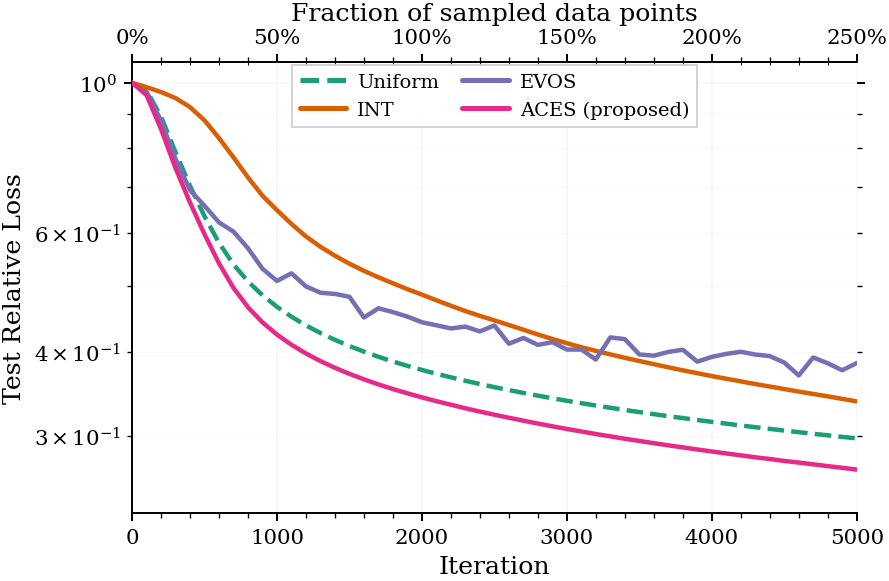

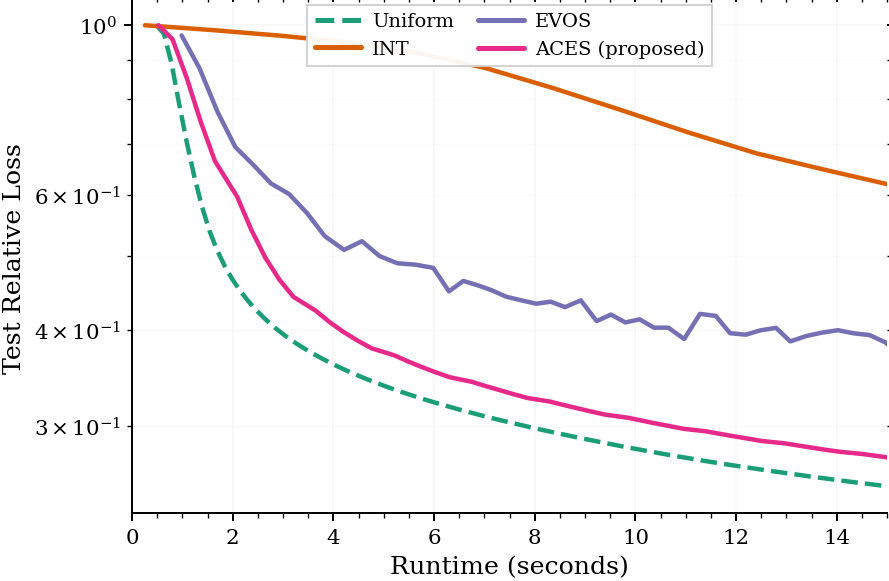

In [4]:
# NS1024 main comparison
recalculate = False
save_path = "ns1024_depth3_re10000.pkl"
ENTITY = "bnl-lemon"
PROJECT = "nips-inr-sampling"
RUN_GROUP = "paper"
TITLE_FILTER_REGEX = r"NS1024.*re_10000_"
METRIC = "test_rel_loss"

SELECTED_METHODS = ["random", "NMT", "EVOS", "adaptive_best_fast"]

FIG_OUTPUT_ITER = "/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/ns1024_re10000_iter_vs_test_rel_loss_selected.png"
FIG_OUTPUT_TIME = "/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/ns1024_re10000_time_vs_test_rel_loss_selected.png"

aggregated_data, run_counts = load_or_collect_aggregates(
    entity=ENTITY,
    project=PROJECT,
    title_filter_regex=TITLE_FILTER_REGEX,
    metric=METRIC,
    save_path=save_path,
    recalculate=recalculate,
    run_group=RUN_GROUP,
)
report_methods(aggregated_data, run_counts, SELECTED_METHODS)

METHOD_LABELS_OVERRIDE = {
    "adaptive_best_fast": "ACES (proposed)",
    "adaptive_best": "ACES (proposed)",
    "adaptive_unbiased": "ACES (w/o bias weight)",
    "adaptive_large_bias": "Adaptive (Large Bias)",
    "EVOS": "EVOS",
    "NMT": "INT",
    "random": "Uniform",
    "full": "Full",
}

fig1, ax1, fig2, ax2 = draw_experiment(
    aggregated_data=aggregated_data,
    selected_methods=SELECTED_METHODS,
    output_iter=FIG_OUTPUT_ITER,
    output_time=FIG_OUTPUT_TIME,
    method_labels_override=METHOD_LABELS_OVERRIDE,
    iter_kwargs={
        "title": "",
        "y_log": True,
        "legend_ncol": 2,
    },
    runtime_kwargs={
        "legend_ncol": 2,
        "time_cutoff": 15.0,
    },
)

Loading pre-collected data from: pool_depth3.pkl
Data collected. Methods available:
  EVOS: n=5
  NMT: n=5
  adaptive_best_fast: n=5
  random: n=5

Selected methods are ready to draw.
Saved: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/Pool_iter_vs_test_rel_loss_selected.png
Saved: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/Pool_iter_vs_test_rel_loss_selected.pdf
Methods drawn (iter-loss): ['random', 'NMT', 'EVOS', 'adaptive_best_fast']
Saved: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/Pool_time_vs_test_rel_loss_selected.png
Saved: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/Pool_time_vs_test_rel_loss_selected.pdf
Methods drawn (runtime-loss): ['random', 'NMT', 'EVOS', 'adaptive_best_fast']


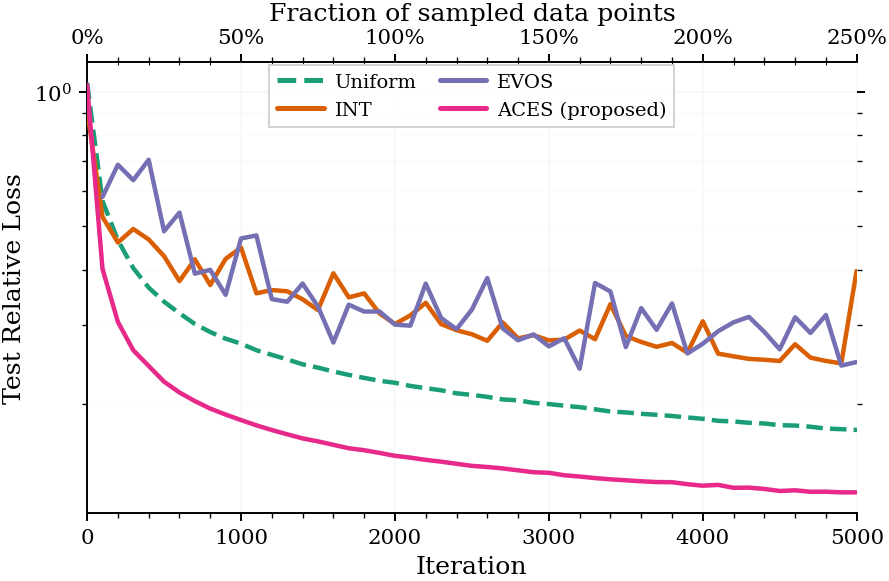

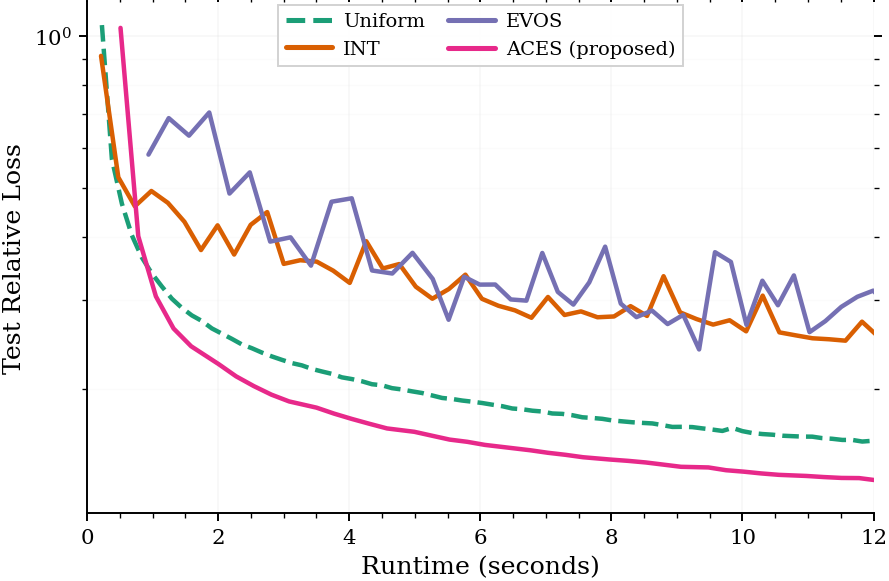

In [5]:
# Pool main comparison
recalculate = False
save_path = "pool_depth3.pkl"
ENTITY = "bnl-lemon"
PROJECT = "nips-inr-sampling"
RUN_GROUP = "paper"
TITLE_FILTER_REGEX = r"Pool.*"
METRIC = "test_rel_loss"

SELECTED_METHODS = ["random", "NMT", "EVOS", "adaptive_best_fast"]

FIG_OUTPUT_ITER = "/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/Pool_iter_vs_test_rel_loss_selected.png"
FIG_OUTPUT_TIME = "/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/Pool_time_vs_test_rel_loss_selected.png"

aggregated_data2, run_counts2 = load_or_collect_aggregates(
    entity=ENTITY,
    project=PROJECT,
    title_filter_regex=TITLE_FILTER_REGEX,
    metric=METRIC,
    save_path=save_path,
    recalculate=recalculate,
    run_group=RUN_GROUP,
)
report_methods(aggregated_data2, run_counts2, SELECTED_METHODS)

METHOD_LABELS_OVERRIDE = {
    "adaptive_best_fast": "ACES (proposed)",
    "adaptive_best": "ACES (proposed)",
    "adaptive_unbiased": "ACES (w/o bias weight)",
    "adaptive_large_bias": "Adaptive (Large Bias)",
    "EVOS": "EVOS",
    "NMT": "INT",
    "random": "Uniform",
    "full": "Full",
}

fig1, ax1, fig2, ax2 = draw_experiment(
    aggregated_data=aggregated_data2,
    selected_methods=SELECTED_METHODS,
    output_iter=FIG_OUTPUT_ITER,
    output_time=FIG_OUTPUT_TIME,
    method_labels_override=METHOD_LABELS_OVERRIDE,
    iter_kwargs={
        "legend_ncol": 2,
    },
    runtime_kwargs={
        "legend_ncol": 2,
        "time_cutoff": 12.0,
    },
)

Loading pre-collected data from: ns1024_depth6_ablation.pkl
Data collected. Methods available:
  adaptive_best: n=1
  adaptive_unbiased: n=1
  adaptive_with_no_area: n=1
  grid_linear: n=2

Selected methods are ready to draw.


Saved: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/ns1024_re10000_ablation.png
Saved: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/ns1024_re10000_ablation.pdf
Methods drawn (iter-loss): ['adaptive_unbiased', 'adaptive_best', 'grid_linear']


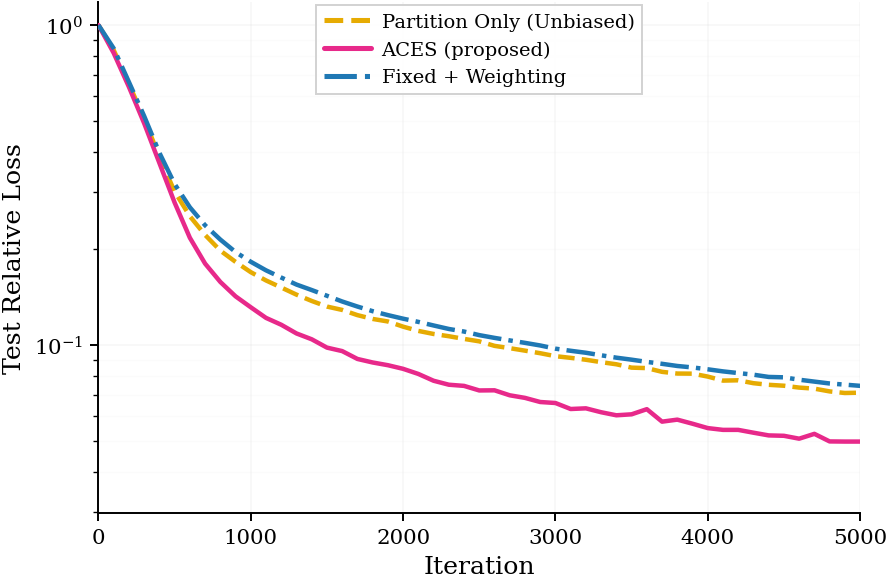

In [4]:
# NS1024 ablation comparison
recalculate = False
save_path = "ns1024_depth6_ablation.pkl"
ENTITY = "bnl-lemon"
PROJECT = "NIPS-inr-ablation"
TITLE_FILTER_REGEX = r"NS1024.*re_10000_.*t100"
METRIC = "test_rel_loss"

SELECTED_METHODS = ["adaptive_unbiased", "grid_linear", "adaptive_best"]

FIG_OUTPUT_ITER = "/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/ns1024_re10000_ablation.png"

aggregated_data3, run_counts3 = load_or_collect_aggregates(
    entity=ENTITY,
    project=PROJECT,
    title_filter_regex=TITLE_FILTER_REGEX,
    metric=METRIC,
    save_path=save_path,
    recalculate=recalculate,
)
report_methods(aggregated_data3, run_counts3, SELECTED_METHODS)

METHOD_LABELS_OVERRIDE = {
    "adaptive_best_fast": "Adaptive (Best Fast)",
    "adaptive_best": "ACES (proposed)",
    "adaptive_unbiased": "Partition Only (Unbiased)",
    "adaptive_large_bias": "Adaptive (Large Bias)",
    "EVOS": "EVOS",
    "NMT": "INT",
    "random": "Uniform",
    "full": "Full",
    "grid_linear": "Fixed + Weighting",
}

METHOD_COLORS_OVERRIDE = {
    "adaptive_best": METHOD_PALETTE["adaptive_best_fast"],
}

fig1, ax1, _, _ = draw_experiment(
    aggregated_data=aggregated_data3,
    selected_methods=SELECTED_METHODS,
    output_iter=FIG_OUTPUT_ITER,
    output_time=None,
    method_labels_override=METHOD_LABELS_OVERRIDE,
    method_colors_override=METHOD_COLORS_OVERRIDE,
    iter_kwargs={
        "legend_ncol": 1,
        "show_sampling_percent_axis": False,
    },
)

Loading pre-collected data from: pool_depth3_ablation.pkl
Data collected. Methods available:
  adaptive_best_fast: n=2
  adaptive_unbiased: n=2
  adaptive_with_no_area: n=2
  grid_linear: n=2
  random: n=2

Selected methods are ready to draw.
Saved: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/bubble_ablation.png
Saved: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/bubble_ablation.pdf
Methods drawn (iter-loss): ['random', 'adaptive_unbiased', 'grid_linear', 'adaptive_best_fast']


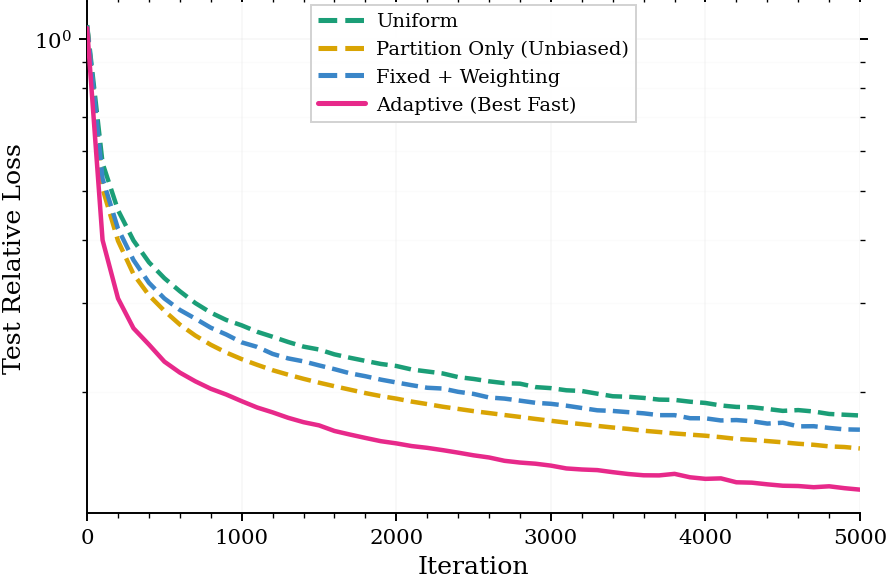

In [20]:
# NS1024 ablation comparison
recalculate = False
save_path = "pool_depth3_ablation.pkl"
ENTITY = "bnl-lemon"
PROJECT = "Bubble-inr-ablation"
TITLE_FILTER_REGEX = r"Pool.*"
METRIC = "test_rel_loss"

SELECTED_METHODS = ["random", "adaptive_unbiased", "grid_linear", "adaptive_best_fast"]

FIG_OUTPUT_ITER = "/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/bubble_ablation.png"

aggregated_data3, run_counts3 = load_or_collect_aggregates(
    entity=ENTITY,
    project=PROJECT,
    title_filter_regex=TITLE_FILTER_REGEX,
    metric=METRIC,
    save_path=save_path,
    recalculate=recalculate,
)
report_methods(aggregated_data3, run_counts3, SELECTED_METHODS)

METHOD_LABELS_OVERRIDE = {
    "adaptive_best_fast": "Adaptive (Best Fast)",
    "adaptive_best": "ACES (proposed)",
    "adaptive_unbiased": "Partition Only (Unbiased)",
    "adaptive_large_bias": "Adaptive (Large Bias)",
    "EVOS": "EVOS",
    "NMT": "INT",
    "random": "Uniform",
    "full": "Full",
    "grid_linear": "Fixed + Weighting",
}

METHOD_COLORS_OVERRIDE = {
    "adaptive_best": METHOD_PALETTE["adaptive_best_fast"],
}

fig1, ax1, _, _ = draw_experiment(
    aggregated_data=aggregated_data3,
    selected_methods=SELECTED_METHODS,
    output_iter=FIG_OUTPUT_ITER,
    output_time=None,
    method_labels_override=METHOD_LABELS_OVERRIDE,
    method_colors_override=METHOD_COLORS_OVERRIDE,
    iter_kwargs={
        "legend_ncol": 1,
        "show_sampling_percent_axis": False,
    },
)

